In [1]:
import numpy as np  # import numerical python
import matplotlib.pyplot as plt  # import plotting functions
import seaborn as sns  # import nicer plotting functions
import pandas as pd
import polars as pl
import tifffile as tiff
from tifffile import imwrite, imread
from copy import deepcopy
import os
import time

import sys

sys.path.append("../..")

from src import IOFunctions

IO = IOFunctions.IO_Functions()

from src import PlottingFunctions

plotter = PlottingFunctions.Plotter(dark_background=False)

from src import ImageAnalysisFunctions

I_AF = ImageAnalysisFunctions.Image_Analysis_Functions()

from src import sCMOSFunctions

sCMOS = sCMOSFunctions.sCMOS_Functions()

from src import PSFFunctions

PSF = PSFFunctions.PSF_Functions()

from src import SpectralFunctions

S_F = SpectralFunctions.Spectral_Funcs()

from src import MaskFunctions

M_F = MaskFunctions.Mask_Functions()

from src import SpotDetectionFunctions

SD_F = SpotDetectionFunctions.SpotDetection_Functions()

from src import SR_Functions

SRes_F = SR_Functions.SuperRes_Functions()

from src import HelperFunctions

H_F = HelperFunctions.Helper_Functions()

from src import SM_extractionfunctions

SM_E = SM_extractionfunctions.extract_SMs()

from src.DriftCorrectionFunctions import (
    Drift_Correction_Functions,
    DriftMethod,
    DriftParameters,
    DriftResult,
    CoordinateProcessor

)

import types

smoothing_function = types.SimpleNamespace()
smoothing_function.args = {"sigma": 1.5}
smoothing_function.extent = 1.5
smoothing_function.smoothing_function = sCMOS.gaussian_filter_stack
smoothing_function.data_arg = "image"

/tmp/ipykernel_291802/1850317328.py:22: DeprecationWarning: PlottingFunctions.Plotter is deprecated and will be removed in a future version. Use PlottingBase.PublicationPlotter directly instead.
  plotter = PlottingFunctions.Plotter(dark_background=False)


In [2]:
data_folder = "../Camera_Calibrations/Ximea_Camera/"
gain = IO.read_tiff(os.path.join(data_folder, "gain.tif"))
offset = IO.read_tiff(os.path.join(data_folder, "offset.tif"))
variance = IO.read_tiff(os.path.join(data_folder, "variance.tif"))
readnoise = IO.read_tiff(os.path.join(data_folder, "readnoise.tif"))
rqe = IO.read_tiff(os.path.join(data_folder, "rqe.tif"))
R, G, B, wavelength = S_F.getpixelefficiency()

In [3]:
objective_T = S_F.getobjectiveefficiency(wavelength)

In [4]:
folder = '/scratch/sycamore-asap/ASAP_Members_Other_Imaging_Data/Brendan/20250819_TetraspeckCalibration'

In [5]:
wavelength = wavelength
pixel_QYs = np.vstack([B, G, R])

In [6]:
colours = ['488', '561', '638']
powers = ['1mW', '2mW', '3mW', '4mW', '6mW', '8mW', '10mW']

In [7]:
mean_photons_all = 0
loc_prec_all = 0
mean_photons_red_all = 0
mean_photons_green_all = 0
mean_photons_blue_all = 0
prec_red_all = 0
prec_green_all = 0
prec_blue_all = 0


for colour in colours:
    for power in powers:
        single_molecule_database_file = [x for x in H_F.file_search(folder, '', '_molecule_') if power in x and colour in x][0]
        single_frame_database_file = [x for x in H_F.file_search(folder, '', '_frame_') if power in x and colour in x][0]

        single_frame_database= pd.read_hdf(single_frame_database_file)
        single_molecule_database= pd.read_hdf(single_molecule_database_file)
    
        single_molecule_database = single_molecule_database[single_molecule_database['frame']>50]
        
        mean_photons = np.zeros(single_molecule_database['molecular_index'].size)
        loc_prec_x = np.zeros(single_molecule_database['molecular_index'].size)
        loc_prec_y = np.zeros(single_molecule_database['molecular_index'].size)
        loc_prec = np.zeros(single_molecule_database['molecular_index'].size)
        
        mean_red = np.zeros(single_molecule_database['molecular_index'].size)
        mean_green = np.zeros(single_molecule_database['molecular_index'].size)
        mean_blue = np.zeros(single_molecule_database['molecular_index'].size)
        
        prec_red = np.zeros(single_molecule_database['molecular_index'].size)
        prec_green = np.zeros(single_molecule_database['molecular_index'].size)
        prec_blue = np.zeros(single_molecule_database['molecular_index'].size)
        
        mean_photons_red = np.zeros(single_molecule_database['molecular_index'].size)
        mean_photons_green = np.zeros(single_molecule_database['molecular_index'].size)
        mean_photons_blue = np.zeros(single_molecule_database['molecular_index'].size)
    
        for i in range(single_molecule_database['molecular_index'].size):
            mol = single_molecule_database.molecular_index.iloc[i]
            stack = single_molecule_database.stack_index.iloc[i]
            
            hold = single_frame_database[single_frame_database['stack_index']==stack]
            hold = hold[hold['molecular_index']==mol]
        
            loc_prec_x[i] = np.std(hold['xc'])*69
            loc_prec_y[i] = np.std(hold['yc'])*69
            loc_prec[i] = (loc_prec_x[i] + loc_prec_y[i])/2
        
            mean_photons[i] = np.mean(hold['photons'])
        
            mean_red[i] = np.mean(hold['A_R'])
            mean_green[i] = np.mean(hold['A_G'])
            mean_blue[i] = np.mean(hold['A_B'])
        
            prec_red[i] = np.std(hold['A_R'])/mean_red[i]
            prec_green[i] = np.std(hold['A_G'])/mean_green[i]
            prec_blue[i] = np.std(hold['A_B'])/mean_blue[i]
        
            mean_photons_red[i] = mean_photons[i]*mean_red[i]
            mean_photons_green[i] = mean_photons[i]*mean_green[i]
            mean_photons_blue[i] = mean_photons[i]*mean_blue[i]
    
        mean_photons_all = np.append(mean_photons,mean_photons_all)
        loc_prec_all = np.append(loc_prec,loc_prec_all)
    
        mean_photons_red_all = np.append(mean_photons_red,mean_photons_red_all)
        mean_photons_green_all = np.append(mean_photons_green,mean_photons_green_all)
        mean_photons_blue_all = np.append(mean_photons_blue,mean_photons_blue_all)
    
        prec_red_all = np.append(prec_red,prec_red_all)
        prec_green_all = np.append(prec_green,prec_green_all)
        prec_blue_all = np.append(prec_blue,prec_blue_all)

    
    

mean_color_all = [mean_photons_red_all,mean_photons_green_all,mean_photons_blue_all]
prec_color_all = [prec_red_all,np.multiply(np.sqrt(2),prec_green_all),prec_blue_all]
    

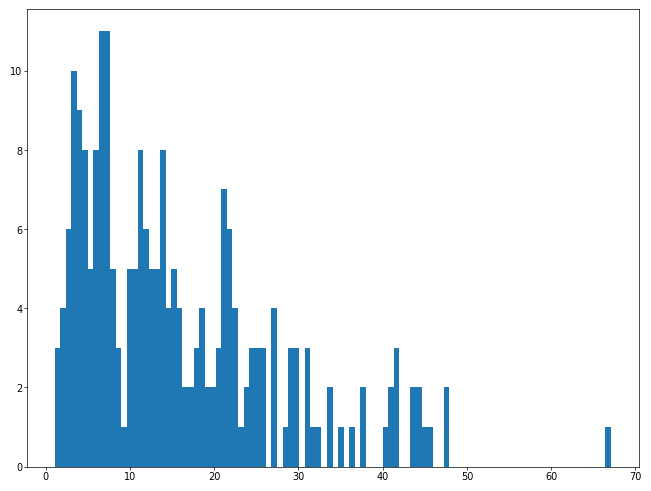

In [8]:
plt.hist(single_molecule_database['background_photons'], 100);
plt.show()

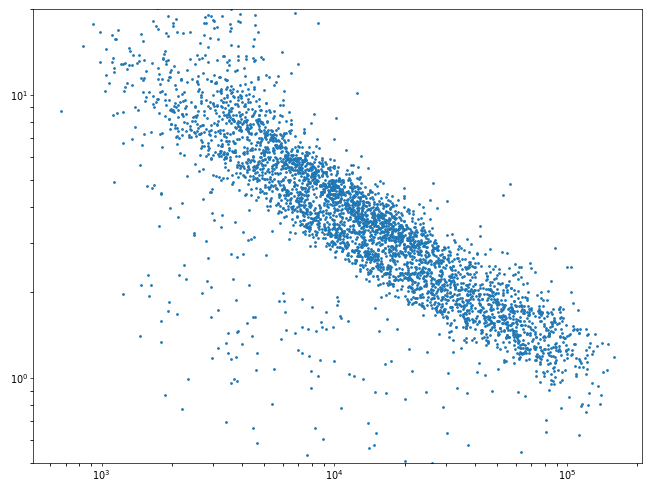

In [30]:
plt.scatter(mean_photons_all,loc_prec_all,s=1)
plt.ylim([0.5,20])
plt.xscale('log')
plt.yscale('log')

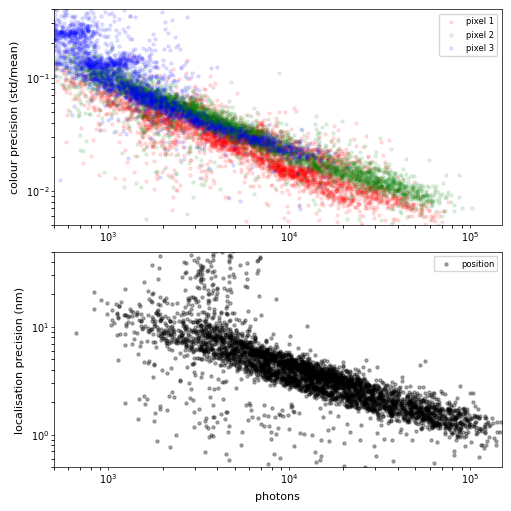

In [31]:

fig, axs = plotter.one_column_plot(
        npanels= 2,
        ratios=[1,1],
        height=5,
        width=5,
    )
ax1 = axs[0]
ax2 = axs[1]

ax1.scatter(mean_photons_red_all,prec_red_all,alpha=0.1,color='r',s=5)
ax1.scatter(mean_photons_green_all,np.sqrt(2)*prec_green_all,alpha=0.1,color='g',s=5)
ax1.scatter(mean_photons_blue_all,prec_blue_all,alpha=0.1,color='b',s=5)
ax1.set_yscale('log')
ax1.set_ylim([0.005,0.4])
ax1.set_xlim([0.5e3,1.5E5])
ax1.set_xscale('log')

ax2.scatter(mean_photons_all,loc_prec_all,alpha=0.3,color='black',s=5)
ax2.set_ylim([0.5,50])
ax2.set_xlim([0.5e3,1.5E5])

plt.yscale('log')
plt.xscale('log')

ax1.set_ylabel('colour precision (std/mean)')
ax2.set_ylabel('localisation precision (nm)')
ax2.set_xlabel('photons')

ax1.legend(['pixel 1','pixel 2','pixel 3'])
ax2.legend(['position'])

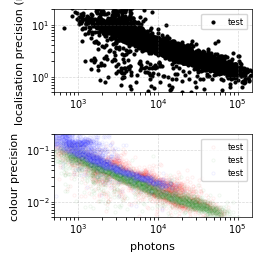

In [18]:
fig, axs = plotter.one_column_plot(
        npanels= 2,
        ratios=[1,1],
        height=2.5,
        width=2.5,
    )
ax1 = axs[0]
ax2 = axs[1]

plotter.scatter_plot(
        ax1,
        mean_photons_all,
        loc_prec_all,
        xlim= [500,1.5e5],
        ylim= [0.5,20],
        label="test",
        edgecolor = "k",
        facecolor = "white",
        s = 5,
        lw = 0.75,
        xaxislabel= " ",
        yaxislabel = "localisation precision (nm)",
        alpha = 1,
        marker= "o",
        rasterized = False,
    )
ax1.set_xscale('log')
ax1.set_yscale('log')


plotter.scatter_plot(
        ax2,
        mean_photons_red_all,
        prec_red_all,
        xlim= [500,1.5e5],
        ylim= [0.005,0.20],
        label="test",
        edgecolor = "r",
        facecolor = "white",
        s = 5,
        lw = 0.75,
        xaxislabel= "x axis",
        yaxislabel = "y axis",
        alpha = 0.06,
        marker= "o",
        rasterized = False,
    )

plotter.scatter_plot(
        ax2,
        mean_photons_green_all,
        np.multiply(np.sqrt(1),prec_green_all),
        xlim= [500,1.5e5],
        ylim= [0.005,0.20],
        label="test",
        edgecolor = "g",
        facecolor = "white",
        s = 5,
        lw = 0.75,
        xaxislabel= "x axis",
        yaxislabel = "y axis",
        alpha = 0.06,
        marker= "o",
        rasterized = False,
    )

plotter.scatter_plot(
        ax2,
        mean_photons_blue_all,
        prec_blue_all,
        xlim= [500,1.5e5],
        ylim= [0.005,0.20],
        label="test",
        edgecolor = "b",
        facecolor = "white",
        s = 5,
        lw = 0.75,
        xaxislabel= "photons",
        yaxislabel = "colour precision",
        alpha = 0.06,
        marker= "o",
        rasterized = False,
    )
ax2.set_xscale('log')
ax2.set_yscale('log')

#fig_savefolder = r'C:\Users\kbhc756\temp_data\BeadCalibrationData'
#plt.savefig(os.path.join(fig_savefolder, 'Precision_Bead_638_excitation.svg'), dpi=600, format='svg')


/tmp/ipykernel_291802/3880593991.py:10: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


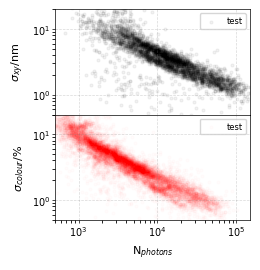

In [19]:
fig, axs = plotter.one_column_plot(
        npanels= 2,
        ratios=[1,1],
        height=2.5,
        width=2.5,
    )
ax1 = axs[0]
ax2 = axs[1]

fig.tight_layout()    
fig.subplots_adjust(hspace=0)                                            

plotter.scatter_plot(
        ax1,
        mean_photons_all,
        loc_prec_all,
        xlim= [500,1.5e5],
        ylim= [0.5,20],
        label="test",
        edgecolor = "k",
        facecolor = "k",
        s = 5,
        lw = 0.75,
        xaxislabel= " ",
        yaxislabel = r"$\sigma_{xy}$/nm",
        alpha = 0.05,
        marker= "o",
        rasterized = True,
    )
ax1.set_xscale('log')
ax1.set_yscale('log')

plotter.scatter_plot(
        ax2,
        mean_color_all,
        np.multiply(100,prec_color_all),
        xlim= [500,1.5e5],
        ylim= [0.5,20],
        label="test",
        edgecolor = "r",
        facecolor = "r",
        s = 5,
        lw = 0.75,
        xaxislabel= r"N$_{photons}$",
        yaxislabel = r"$\sigma_{colour}$/%",
        alpha = 0.01,
        marker= "o",
        rasterized = True,
    )
ax2.set_xscale('log')
ax2.set_yscale('log')

#fig_savefolder = r'C:\Users\kbhc756\temp_data\BeadCalibrationData'
#plt.savefig(os.path.join(fig_savefolder, 'Precision_Beads_all_excitation_scaledGreen.svg'), dpi=600, format='svg')

offset loc =  -0.580634146257


<>:40: SyntaxWarning: invalid escape sequence '\s'
<>:40: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_291802/3918501377.py:40: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel("$\sigma$xy")


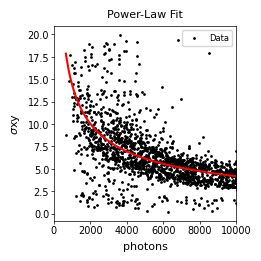

In [20]:

import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

# Define the power-law function
def power_law(x, a,c):
    return a * np.power(x, -0.5) + c

loc_prec_all_cleaned_a = loc_prec_all[loc_prec_all > 0.01]
mean_photons_all_cleaned = mean_photons_all[loc_prec_all > 0.01]

loc_prec_all_cleaned = loc_prec_all_cleaned_a[loc_prec_all_cleaned_a < 20]
mean_photons_all_cleaned = mean_photons_all_cleaned[loc_prec_all_cleaned_a < 20]

loc_prec_all_cleaned = loc_prec_all_cleaned[mean_photons_all_cleaned < 2E4]
mean_photons_all_cleaned = mean_photons_all_cleaned[mean_photons_all_cleaned < 2E4]


x_data = mean_photons_all_cleaned
x_data = x_data[~np.isnan(x_data)]
sorted_indices = np.argsort(x_data)
x_data_loc = x_data[sorted_indices]


y_data = loc_prec_all_cleaned
y_data = y_data[~np.isnan(y_data)]
y_data_loc = y_data[sorted_indices]

weights = 1 / x_data_loc#(np.random.normal(np.mean(x_data), np.std(x_data), size=x_data.size))  # Example weights

# Fit the power-law model to the data
params, covariance = curve_fit(power_law, x_data_loc, y_data_loc,sigma=weights,absolute_sigma=True)
# Extract fitted parameters
a_fit_loc,offset_loc = params

# Plot the data and the fitted curve
plt.scatter(x_data_loc, y_data_loc, label="Data", color="black",alpha=1,s=1)
plt.plot(x_data_loc, power_law(x_data_loc, a_fit_loc,offset_loc),color="red")
plt.xlabel("photons")
plt.ylabel("$\sigma$xy")
plt.legend()
plt.title("Power-Law Fit")
plt.xscale('linear')
plt.yscale('linear')
plt.xlim([0,1E4])
print('offset loc = ',str(offset_loc))

offset color =  -1.13562383878


<>:43: SyntaxWarning: invalid escape sequence '\s'
<>:43: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_291802/160589446.py:43: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel("$\sigma$ colour / mean colour")


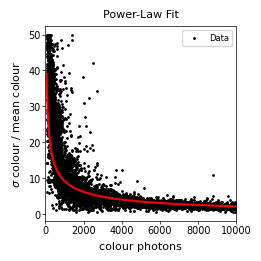

In [21]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

# Define the power-law function
def power_law(x, a,c):
    return a * np.power(x, -0.5) + c

prec_color_all_scaled = np.multiply(prec_color_all,100)
mean_color_all_stack = np.stack(mean_color_all)

prec_color_all_cleaned_a = prec_color_all_scaled[prec_color_all_scaled > 0.5]
mean_color_all_cleaned = mean_color_all_stack[prec_color_all_scaled > 0.5]

prec_color_all_cleaned = prec_color_all_cleaned_a[prec_color_all_cleaned_a < 50]
mean_color_all_cleaned = mean_color_all_cleaned[prec_color_all_cleaned_a < 50]

prec_color_all_cleaned = prec_color_all_cleaned[mean_color_all_cleaned < 2E4]
mean_color_all_cleaned = mean_color_all_cleaned[mean_color_all_cleaned < 2E4]


x_data = mean_color_all_cleaned
x_data = x_data[~np.isnan(x_data)]
sorted_indices = np.argsort(x_data)
x_data_color = x_data[sorted_indices]


y_data = prec_color_all_cleaned
y_data = y_data[~np.isnan(y_data)]
y_data_color = y_data[sorted_indices]

weights = 1 / x_data_color#(np.random.normal(np.mean(x_data), np.std(x_data), size=x_data.size))  # Example weights

# Fit the power-law model to the data
params, covariance = curve_fit(power_law, x_data_color, y_data_color,sigma=weights,absolute_sigma=True)
# Extract fitted parameters
a_fit_color,offset_color = params

# Plot the data and the fitted curve
plt.scatter(x_data_color, y_data_color, label="Data", color="black",alpha=1,s=1)
plt.plot(x_data_color, power_law(x_data_color, a_fit_color,offset_color),color="red")
plt.xlabel("colour photons")
plt.ylabel("$\sigma$ colour / mean colour")
plt.legend()
plt.title("Power-Law Fit")
plt.xscale('linear')
plt.yscale('linear')
plt.xlim([0,1E4])
print('offset color = ',str(offset_color))

In [36]:
power_law(22000,a_fit_color,offset_color)

1.0665820746437693

In [42]:
def mad(arr):
    """ Median Absolute Deviation: a "Robust" version of standard deviation.
        Indices variabililty of the sample.
        https://en.wikipedia.org/wiki/Median_absolute_deviation 
    """
    arr = np.ma.array(arr).compressed() # should be faster to not use masked arrays.
    med = np.median(arr)
    return np.median(np.abs(arr - med))

In [43]:
# single fluorescent protein photon ranges

# from https://pubs.acs.org/doi/10.1021/acs.chemrev.7b00767

vals = np.array([686, 550, 262, 1000, 1000, 1000, 675, 725, 313])
perc_25_fp, perc_75_fp = np.percentile(vals, [25, 75])
print(np.median(vals))
print(mad(vals))
print(perc_25_fp)
print(perc_75_fp)

686.0
314.0
550.0
1000.0


In [44]:
# single dye photon ranges

# from Steen, P. R. et al. Nat Methods 21, 1755–1762 (2024).
# and from Dempsey, G. T., Vaughan, J. C., Chen, K. H., Bates, M. & Zhuang, X. Nat Methods 8, 1027–1036 (2011).


vals = np.array([1341, 1193, 1231, 1493, 6241, 4884, 11022, 4968, 19714, 5202, 5873, 4433, 6337, 2753, 2073, 2811, 2969,
                3879, 23195, 11600, 2429, 1338, 7801, 17090, 23327, 18448, 8273, 12024, 10399, 12731, 14440, 10348])
perc_25_od, perc_75_od = np.percentile(vals, [25, 75])
print(np.median(vals))
print(mad(vals))

print(perc_25_od)
print(perc_75_od)

6057.0
4316.5
2796.5
11706.0


/tmp/ipykernel_291802/3152302492.py:12: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


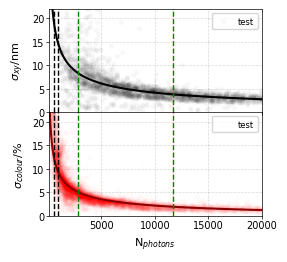

In [41]:
x_data = np.logspace(np.log10(100),6,1000)

fig, axs = plotter.one_column_plot(
        npanels= 2,
        ratios=[1,1],
        height=2.46,
    width=2.6779528,
    )
ax1 = axs[0]
ax2 = axs[1]

fig.tight_layout()
fig.subplots_adjust(hspace=0)                                            

plotter.scatter_plot(
        ax1,
        mean_photons_all,
        loc_prec_all,
        xlim= [100,2e4],
        ylim= [0,20],
        label="test",
        edgecolor = "k",
        facecolor = "k",
        s = 50,
        lw = 0.0,
        xaxislabel= " ",
        yaxislabel = r"$\sigma_{xy}$/nm",
        alpha = 0.03,
        marker= ".",
        rasterized = True,
    )
ax1.set_xscale('linear')
ax1.set_yscale('linear')

plotter.scatter_plot(
        ax2,
        mean_color_all,
        np.multiply(100,prec_color_all),
        xlim= [100,2e4],
        ylim= [0,20],
        label="test",
        edgecolor = "r",
        facecolor = "r",
        s = 50,
        lw = 0.0,
        xaxislabel= r"N$_{photons}$",
        yaxislabel = r"$\sigma_{colour}$/%",
        alpha = 0.01,
        marker= ".",
        rasterized = True,
    )
ax2.set_xscale('linear')
ax2.set_yscale('linear')


plotter.line_plot(
        ax1,
        x = x_data,
        y = power_law(x_data, a_fit_loc,offset_loc),
        xlim= [100,2e4],
        ylim= [0,22],
        color ="k",
        lw = 1.5,
        label = "",
        xaxislabel= " ",
        yaxislabel = r"$\sigma_{xy}$/nm",
        ls="-",
        alpha= 1)

plotter.line_plot(
        ax2,
        x = x_data,
        y = power_law(x_data, a_fit_color,offset_color),
        xlim= [100,2e4],
        ylim= [0,22],
        color ="darkred",
        lw = 1.5,
        label = "",
        xaxislabel= r"N$_{photons}$",
        yaxislabel = r"$\sigma_{colour}$/%",
        ls="-",
        alpha= 1)

ax2.axvline(x=perc_25_fp, ymin=0, ymax=25, lw=1, color='black', ls='--')
ax2.axvline(x=perc_75_fp, ymin=0, ymax=25, lw=1, color='black', ls='--')
ax1.axvline(x=perc_25_fp, ymin=0, ymax=25, lw=1, color='black', ls='--')
ax1.axvline(x=perc_75_fp, ymin=0, ymax=25, lw=1, color='black', ls='--')

ax2.axvline(x=perc_25_od, ymin=0, ymax=25, lw=1, color='green', ls='--')
ax2.axvline(x=perc_75_od, ymin=0, ymax=25, lw=1, color='green', ls='--')
ax1.axvline(x=perc_25_od, ymin=0, ymax=25, lw=1, color='green', ls='--')
ax1.axvline(x=perc_75_od, ymin=0, ymax=25, lw=1, color='green', ls='--')

ax1.set_xticklabels([])
#fig_savefolder = r'C:\Users\kbhc756\temp_data\BeadCalibrationData'
plt.savefig('Precision_Beads_all_excitation_scaledGreen_powerLawFitsLinear.svg', dpi=600, format='svg')
    